In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/laptop_price.csv")
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [4]:
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution',
       'CPU_Company', 'CPU_Type', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Memory',
       'GPU_Company', 'GPU_Type', 'OpSys', 'Weight (kg)', 'Price (Euro)'],
      dtype='object')

In [4]:
df["Memory"].value_counts().head(20)

Memory
256GB SSD               412
1TB HDD                 215
500GB HDD               124
512GB SSD               114
128GB SSD +  1TB HDD     94
128GB SSD                74
256GB SSD +  1TB HDD     73
32GB Flash Storage       36
2TB HDD                  16
512GB SSD +  1TB HDD     14
1TB SSD                  14
64GB Flash Storage       13
256GB SSD +  2TB HDD     10
256GB Flash Storage       8
16GB Flash Storage        7
1.0TB Hybrid              7
32GB SSD                  6
180GB SSD                 5
128GB Flash Storage       4
512GB SSD +  2TB HDD      3
Name: count, dtype: int64

In [5]:
df["Memory"].unique()[:20]

array(['128GB SSD', '128GB Flash Storage', '256GB SSD', '512GB SSD',
       '500GB HDD', '256GB Flash Storage', '1TB HDD',
       '32GB Flash Storage', '128GB SSD +  1TB HDD',
       '256GB SSD +  256GB SSD', '64GB Flash Storage',
       '256GB SSD +  1TB HDD', '256GB SSD +  2TB HDD', '32GB SSD',
       '2TB HDD', '64GB SSD', '1.0TB Hybrid', '512GB SSD +  1TB HDD',
       '1TB SSD', '256GB SSD +  500GB HDD'], dtype=object)

In [6]:
df["Memory_Clean"] = df["Memory"].str.replace(" ", "", regex=False)

In [7]:
df[["Memory", "Memory_Clean"]].head(10)

,Memory,Memory_Clean
0,128GB SSD,128GBSSD
1,128GB Flash Storage,128GBFlashStorage
2,256GB SSD,256GBSSD
3,512GB SSD,512GBSSD
4,256GB SSD,256GBSSD
5,500GB HDD,500GBHDD
6,256GB Flash Storage,256GBFlashStorage
7,256GB Flash Storage,256GBFlashStorage
8,512GB SSD,512GBSSD
9,256GB SSD,256GBSSD


In [8]:
df["SSD_GB"] = df["Memory_Clean"].str.extract(
    r"(\d+(?:\.\d+)?)GBSSD"
)[0]

df["SSD_GB"] = pd.to_numeric(df["SSD_GB"], errors="coerce")

In [9]:
tb_ssd = df["Memory_Clean"].str.extract(
    r"(\d+(?:\.\d+)?)TBSSD"
)[0]

tb_ssd = pd.to_numeric(tb_ssd, errors="coerce")

df["SSD_GB"] = df["SSD_GB"].fillna(tb_ssd * 1000)

In [10]:
df["HDD_GB"] = df["Memory_Clean"].str.extract(
    r"(\d+(?:\.\d+)?)GBHDD"
)[0]

df["HDD_GB"] = pd.to_numeric(df["HDD_GB"], errors="coerce")

In [11]:
tb_hdd = df["Memory_Clean"].str.extract(
    r"(\d+(?:\.\d+)?)TBHDD"
)[0]

tb_hdd = pd.to_numeric(tb_hdd, errors="coerce")

df["HDD_GB"] = df["HDD_GB"].fillna(tb_hdd * 1000)

In [12]:
df["SSD_GB"] = df["SSD_GB"].fillna(0)
df["HDD_GB"] = df["HDD_GB"].fillna(0)

In [13]:
df[["SSD_GB", "HDD_GB"]].describe()

,SSD_GB,HDD_GB
count,1275.000000,1275.000000
mean,184.956863,412.674510
std,184.345592,516.132663
min,0.000000,0.000000
25%,0.000000,0.000000
50%,256.000000,0.000000
75%,256.000000,1000.000000
max,1000.000000,2000.000000


In [14]:
df[["Memory", "SSD_GB", "HDD_GB"]].head(20)

,Memory,SSD_GB,HDD_GB
0,128GB SSD,128.0,0.0
1,128GB Flash Storage,0.0,0.0
2,256GB SSD,256.0,0.0
3,512GB SSD,512.0,0.0
4,256GB SSD,256.0,0.0
5,500GB HDD,0.0,500.0
6,256GB Flash Storage,0.0,0.0
7,256GB Flash Storage,0.0,0.0
8,512GB SSD,512.0,0.0
9,256GB SSD,256.0,0.0


In [18]:
df["Flash_GB"] = df["Memory_Clean"].str.extract(
    r"(\d+(?:\.\d+)?)GBFlashStorage"
)[0]

df["Flash_GB"] = pd.to_numeric(df["Flash_GB"], errors="coerce")
df["Flash_GB"] = df["Flash_GB"].fillna(0)

In [19]:
df["Hybrid_GB"] = df["Memory_Clean"].str.extract(
    r"(\d+(?:\.\d+)?)TBHybrid"
)[0]

df["Hybrid_GB"] = pd.to_numeric(df["Hybrid_GB"], errors="coerce")
df["Hybrid_GB"] = df["Hybrid_GB"].fillna(0) * 1000

In [20]:
df[[
    "Memory",
    "SSD_GB",
    "HDD_GB",
    "Flash_GB",
    "Hybrid_GB"
]].head(30)

,Memory,SSD_GB,HDD_GB,Flash_GB,Hybrid_GB
0,128GB SSD,128.0,0.0,0.0,0.0
1,128GB Flash Storage,0.0,0.0,128.0,0.0
2,256GB SSD,256.0,0.0,0.0,0.0
3,512GB SSD,512.0,0.0,0.0,0.0
4,256GB SSD,256.0,0.0,0.0,0.0
5,500GB HDD,0.0,500.0,0.0,0.0
6,256GB Flash Storage,0.0,0.0,256.0,0.0
7,256GB Flash Storage,0.0,0.0,256.0,0.0
8,512GB SSD,512.0,0.0,0.0,0.0
9,256GB SSD,256.0,0.0,0.0,0.0


In [21]:
df["Total_Storage_GB"] = (
    df["SSD_GB"]
    + df["HDD_GB"]
    + df["Flash_GB"]
    + df["Hybrid_GB"]
)

In [22]:
df[[
    "Memory",
    "SSD_GB",
    "HDD_GB",
    "Flash_GB",
    "Hybrid_GB",
    "Total_Storage_GB"
]].head(30)

,Memory,SSD_GB,HDD_GB,Flash_GB,Hybrid_GB,Total_Storage_GB
0,128GB SSD,128.0,0.0,0.0,0.0,128.0
1,128GB Flash Storage,0.0,0.0,128.0,0.0,128.0
2,256GB SSD,256.0,0.0,0.0,0.0,256.0
3,512GB SSD,512.0,0.0,0.0,0.0,512.0
4,256GB SSD,256.0,0.0,0.0,0.0,256.0
5,500GB HDD,0.0,500.0,0.0,0.0,500.0
6,256GB Flash Storage,0.0,0.0,256.0,0.0,256.0
7,256GB Flash Storage,0.0,0.0,256.0,0.0,256.0
8,512GB SSD,512.0,0.0,0.0,0.0,512.0
9,256GB SSD,256.0,0.0,0.0,0.0,256.0


In [23]:
df["Storage_Type"] = df["Memory"].apply(
    lambda x:
    "SSD" if "SSD" in x and "HDD" not in x
    else "HDD" if "HDD" in x and "SSD" not in x
    else "SSD + HDD" if "SSD" in x and "HDD" in x
    else "Flash" if "Flash Storage" in x
    else "Hybrid" if "Hybrid" in x
    else "Other"
)

In [24]:
df["Storage_Type"].value_counts()

Storage_Type
SSD          637
HDD          360
SSD + HDD    200
Flash         70
Hybrid         8
Name: count, dtype: int64

In [25]:
df.drop("Memory_Clean", axis=1, inplace=True)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              1275 non-null   object 
 1   Product              1275 non-null   object 
 2   TypeName             1275 non-null   object 
 3   Inches               1275 non-null   float64
 4   ScreenResolution     1275 non-null   object 
 5   CPU_Company          1275 non-null   object 
 6   CPU_Type             1275 non-null   object 
 7   CPU_Frequency (GHz)  1275 non-null   float64
 8   RAM (GB)             1275 non-null   int64  
 9   Memory               1275 non-null   object 
 10  GPU_Company          1275 non-null   object 
 11  GPU_Type             1275 non-null   object 
 12  OpSys                1275 non-null   object 
 13  Weight (kg)          1275 non-null   float64
 14  Price (Euro)         1275 non-null   float64
 15  SSD_GB               1275 non-null   f

In [27]:
df[[
    "Memory",
    "SSD_GB",
    "HDD_GB",
    "Flash_GB",
    "Hybrid_GB",
    "Total_Storage_GB",
    "Storage_Type"
]].head()

,Memory,SSD_GB,HDD_GB,Flash_GB,Hybrid_GB,Total_Storage_GB,Storage_Type
0,128GB SSD,128.0,0.0,0.0,0.0,128.0,SSD
1,128GB Flash Storage,0.0,0.0,128.0,0.0,128.0,Flash
2,256GB SSD,256.0,0.0,0.0,0.0,256.0,SSD
3,512GB SSD,512.0,0.0,0.0,0.0,512.0,SSD
4,256GB SSD,256.0,0.0,0.0,0.0,256.0,SSD


In [28]:
df["Resolution_Width"] = df["ScreenResolution"].str.extract(
    r"(\d+)x\d+"
)[0]

df["Resolution_Height"] = df["ScreenResolution"].str.extract(
    r"\d+x(\d+)"
)[0]

df["Resolution_Width"] = pd.to_numeric(
    df["Resolution_Width"],
    errors="coerce"
)

df["Resolution_Height"] = pd.to_numeric(
    df["Resolution_Height"],
    errors="coerce"
)

In [29]:
df["Touchscreen"] = df["ScreenResolution"].str.contains(
    "Touchscreen",
    case=False,
    regex=False
).astype(int)

In [30]:
df["IPS"] = df["ScreenResolution"].str.contains(
    "IPS",
    case=False,
    regex=False
).astype(int)

In [31]:
df[[
    "ScreenResolution",
    "Resolution_Width",
    "Resolution_Height",
    "Touchscreen",
    "IPS"
]].head(20)

,ScreenResolution,Resolution_Width,Resolution_Height,Touchscreen,IPS
0,IPS Panel Retina Display 2560x1600,2560,1600,0,1
1,1440x900,1440,900,0,0
2,Full HD 1920x1080,1920,1080,0,0
3,IPS Panel Retina Display 2880x1800,2880,1800,0,1
4,IPS Panel Retina Display 2560x1600,2560,1600,0,1
5,1366x768,1366,768,0,0
6,IPS Panel Retina Display 2880x1800,2880,1800,0,1
7,1440x900,1440,900,0,0
8,Full HD 1920x1080,1920,1080,0,0
9,IPS Panel Full HD 1920x1080,1920,1080,0,1


In [32]:
df["CPU_Type"].value_counts().head(20)

CPU_Type
Core i5 7200U              193
Core i7 7700HQ             147
Core i7 7500U              133
Core i3 6006U               81
Core i7 8550U               73
Core i5 8250U               72
Core i5 6200U               68
Core i7 6500U               43
Core i7 6700HQ              41
Core i3 7100U               35
Celeron Dual Core N3350     33
Core i5 7300HQ              33
Celeron Dual Core N3060     25
Core i7 6600U               18
Pentium Quad Core N4200     14
Core i5 7300U               14
Core i7 7600U               13
Core i5                     12
A9-Series 9420              12
Pentium Quad Core N3710     11
Name: count, dtype: int64

In [54]:
df["CPU_Family"] = df["CPU_Type"].apply(
    lambda x:
    "Core i7" if "Core i7" in x else
    "Core i5" if "Core i5" in x else
    "Core i3" if "Core i3" in x else
    "Core M" if "Core M" in x else
    "Celeron" if "Celeron" in x else
    "Pentium" if "Pentium" in x else
    "A9-Series" if "A9-Series" in x else
    "A8-Series" if "A8-Series" in x else
    "A6-Series" if "A6-Series" in x else
    "A4-Series" if "A4-Series" in x else
    "A12-Series" if "A12-Series" in x else
    "A10-Series" if "A10-Series" in x else
    "Ryzen" if "Ryzen" in x else
    "Atom" if "Atom" in x else
    "E-Series" if "E-Series" in x else
    "Xeon" if "Xeon" in x else
    "FX" if "FX" in x else
    "Cortex" if "Cortex" in x else
    "Other"
)

In [48]:
df[["CPU_Type", "CPU_Family"]].head(20)

,CPU_Type,CPU_Family
0,Core i5,Core i5
1,Core i5,Core i5
2,Core i5 7200U,Core i5
3,Core i7,Core i7
4,Core i5,Core i5
5,A9-Series 9420,NaN
6,Core i7,Core i7
7,Core i5,Core i5
8,Core i7 8550U,Core i7
9,Core i5 8250U,Core i5


In [55]:
df["CPU_Family"].value_counts()

CPU_Family
Core i7       515
Core i5       423
Core i3       134
Celeron        78
Pentium        30
Core M         17
A9-Series      15
Atom           13
A6-Series      11
E-Series        9
A12-Series      8
A10-Series      6
A8-Series       4
Ryzen           4
Xeon            4
FX              2
A4-Series       1
Cortex          1
Name: count, dtype: int64

In [56]:
df["CPU_Family"].isna().sum()

np.int64(0)

In [57]:
df.loc[df["CPU_Family"].isna(), "CPU_Type"].value_counts()

Series([], Name: count, dtype: int64)

In [58]:
df["GPU_Type"].value_counts().head(20)

GPU_Type
HD Graphics 620        280
HD Graphics 520        181
UHD Graphics 620        68
GeForce GTX 1050        66
GeForce GTX 1060        48
GeForce 940MX           43
Radeon 530              41
HD Graphics 500         39
HD Graphics 400         33
GeForce GTX 1070        30
GeForce GTX 1050 Ti     28
GeForce 930MX           25
HD Graphics             23
Radeon R5 M430          20
GeForce 920MX           18
Radeon 520              17
GeForce MX150           15
HD Graphics 615         14
Radeon R7 M445          14
HD Graphics 515         13
Name: count, dtype: int64

In [59]:
df["GPU_Company"].value_counts()

GPU_Company
Intel     704
Nvidia    396
AMD       174
ARM         1
Name: count, dtype: int64

In [60]:
df["GPU_Family"] = df["GPU_Type"].apply(
    lambda x:
    "Nvidia GTX" if "GTX" in x else
    "Nvidia MX" if "MX" in x else
    "Nvidia GeForce" if "GeForce" in x else
    "Intel UHD" if "UHD" in x else
    "Intel HD" if "HD Graphics" in x else
    "AMD Radeon" if "Radeon" in x else
    "Other"
)

In [61]:
df["GPU_Family"].value_counts()

GPU_Family
Intel HD          621
Nvidia GTX        237
AMD Radeon        167
Nvidia MX         115
Intel UHD          68
Other              54
Nvidia GeForce     13
Name: count, dtype: int64

In [62]:
df[["GPU_Type", "GPU_Family"]].head(20)


,GPU_Type,GPU_Family
0,Iris Plus Graphics 640,Other
1,HD Graphics 6000,Intel HD
2,HD Graphics 620,Intel HD
3,Radeon Pro 455,AMD Radeon
4,Iris Plus Graphics 650,Other
5,Radeon R5,AMD Radeon
6,Iris Pro Graphics,Other
7,HD Graphics 6000,Intel HD
8,GeForce MX150,Nvidia MX
9,UHD Graphics 620,Intel UHD


In [63]:
df["OpSys"].value_counts()

OpSys
Windows 10      1048
No OS             66
Linux             58
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [64]:
df["OS_Family"] = df["OpSys"].apply(
    lambda x:
    "Windows" if "Windows" in x else
    "macOS" if "macOS" in x or "Mac OS X" in x else
    "Linux" if "Linux" in x else
    "Chrome OS" if "Chrome OS" in x else
    "Android" if "Android" in x else
    "No OS" if "No OS" in x else
    "Other"
)

In [65]:
df["OS_Family"].value_counts()


OS_Family
Windows      1101
No OS          66
Linux          58
Chrome OS      27
macOS          21
Android         2
Name: count, dtype: int64

In [66]:
df[["OpSys", "OS_Family"]].drop_duplicates()

,OpSys,OS_Family
0,macOS,macOS
2,No OS,No OS
5,Windows 10,Windows
6,Mac OS X,macOS
36,Linux,Linux
50,Android,Android
70,Windows 10 S,Windows
290,Chrome OS,Chrome OS
525,Windows 7,Windows


In [67]:
df.isnull().sum()

Company                0
Product                0
TypeName               0
Inches                 0
ScreenResolution       0
CPU_Company            0
CPU_Type               0
CPU_Frequency (GHz)    0
RAM (GB)               0
Memory                 0
GPU_Company            0
GPU_Type               0
OpSys                  0
Weight (kg)            0
Price (Euro)           0
SSD_GB                 0
HDD_GB                 0
Flash_GB               0
Hybrid_GB              0
Total_Storage_GB       0
Storage_Type           0
Resolution_Width       0
Resolution_Height      0
Touchscreen            0
IPS                    0
CPU_Family             0
GPU_Family             0
OS_Family              0
dtype: int64

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
df.shape

(1275, 28)

In [70]:
df.columns.tolist()

['Company',
 'Product',
 'TypeName',
 'Inches',
 'ScreenResolution',
 'CPU_Company',
 'CPU_Type',
 'CPU_Frequency (GHz)',
 'RAM (GB)',
 'Memory',
 'GPU_Company',
 'GPU_Type',
 'OpSys',
 'Weight (kg)',
 'Price (Euro)',
 'SSD_GB',
 'HDD_GB',
 'Flash_GB',
 'Hybrid_GB',
 'Total_Storage_GB',
 'Storage_Type',
 'Resolution_Width',
 'Resolution_Height',
 'Touchscreen',
 'IPS',
 'CPU_Family',
 'GPU_Family',
 'OS_Family']

In [73]:
df.to_csv(
    r"D:\Smart-Laptop-Price-Predictor\data\laptop_processed.csv",
    index=False
)

In [74]:
import os

print(os.path.exists(
    r"D:\Smart-Laptop-Price-Predictor\data\laptop_processed.csv"
))

True


# Day 4 — Data Preprocessing

In this section, we prepare the feature-engineered dataset for machine learning.

### Tasks
- Load the processed dataset
- Separate features and target
- Identify numerical and categorical columns
- Split the dataset into training and testing sets
- Encode categorical features
- Scale numerical features
- Prepare the final ML pipeline

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(
    r"D:\Smart-Laptop-Price-Predictor\data\laptop_processed.csv"
)

In [3]:
print(df.shape)

(1275, 28)


In [77]:
print(df.isnull().sum().sum())

0


In [4]:
X = df.drop("Price (Euro)", axis=1)
y = df["Price (Euro)"]

In [79]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1275, 27)
y shape: (1275,)


In [80]:
numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

In [81]:
print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)', 'SSD_GB', 'HDD_GB', 'Flash_GB', 'Hybrid_GB', 'Total_Storage_GB', 'Resolution_Width', 'Resolution_Height', 'Touchscreen', 'IPS']

Categorical Columns:
['Company', 'Product', 'TypeName', 'ScreenResolution', 'CPU_Company', 'CPU_Type', 'Memory', 'GPU_Company', 'GPU_Type', 'OpSys', 'Storage_Type', 'CPU_Family', 'GPU_Family', 'OS_Family']


## 3. Removing Redundant Raw Features

We have already extracted useful information from several raw text columns during feature engineering.

Therefore, we remove the original columns and retain their engineered features.

In [5]:
drop_columns = [
    "Product",
    "ScreenResolution",
    "CPU_Type",
    "Memory",
    "GPU_Type",
    "OpSys"
]

X = X.drop(columns=drop_columns)

In [83]:
print("X shape:", X.shape)
print(X.columns.tolist())

X shape: (1275, 21)
['Company', 'TypeName', 'Inches', 'CPU_Company', 'CPU_Frequency (GHz)', 'RAM (GB)', 'GPU_Company', 'Weight (kg)', 'SSD_GB', 'HDD_GB', 'Flash_GB', 'Hybrid_GB', 'Total_Storage_GB', 'Storage_Type', 'Resolution_Width', 'Resolution_Height', 'Touchscreen', 'IPS', 'CPU_Family', 'GPU_Family', 'OS_Family']


In [6]:
numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", numerical_cols)
print("\nCategorical:", categorical_cols)

Numerical: ['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)', 'SSD_GB', 'HDD_GB', 'Flash_GB', 'Hybrid_GB', 'Total_Storage_GB', 'Resolution_Width', 'Resolution_Height', 'Touchscreen', 'IPS']

Categorical: ['Company', 'TypeName', 'CPU_Company', 'GPU_Company', 'Storage_Type', 'CPU_Family', 'GPU_Family', 'OS_Family']


## 4. Train-Test Split

We split the dataset into training and testing sets.

- 80% of the data will be used for training.
- 20% will be used for testing.
- `random_state=42` ensures reproducible results.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1020, 21)
X_test: (255, 21)
y_train: (1020,)
y_test: (255,)


## 5. Encoding and Scaling

Machine learning models require numerical input.

- Categorical features will be converted using One-Hot Encoding.
- Numerical features will be standardized using StandardScaler.
- ColumnTransformer will apply the appropriate transformation to each type of feature.

In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [11]:
X_train_processed = preprocessor.fit_transform(X_train)

In [12]:
X_test_processed = preprocessor.transform(X_test)

In [13]:
print("Before preprocessing:", X_train.shape)
print("After preprocessing:", X_train_processed.shape)

print("Test before:", X_test.shape)
print("Test after:", X_test_processed.shape)

Before preprocessing: (1020, 21)
After preprocessing: (1020, 80)
Test before: (255, 21)
Test after: (255, 80)


In [93]:
print("Training NaN:", X_train_processed.nnz)
print("Testing NaN:", X_test_processed.nnz)

Training NaN: 21420
Testing NaN: 5354


In [94]:
print("X_train NaN:")
print(X_train.isnull().sum())

print("\nX_test NaN:")
print(X_test.isnull().sum())

X_train NaN:
Company                0
TypeName               0
Inches                 0
CPU_Company            0
CPU_Frequency (GHz)    0
RAM (GB)               0
GPU_Company            0
Weight (kg)            0
SSD_GB                 0
HDD_GB                 0
Flash_GB               0
Hybrid_GB              0
Total_Storage_GB       0
Storage_Type           0
Resolution_Width       0
Resolution_Height      0
Touchscreen            0
IPS                    0
CPU_Family             0
GPU_Family             0
OS_Family              0
dtype: int64

X_test NaN:
Company                0
TypeName               0
Inches                 0
CPU_Company            0
CPU_Frequency (GHz)    0
RAM (GB)               0
GPU_Company            0
Weight (kg)            0
SSD_GB                 0
HDD_GB                 0
Flash_GB               0
Hybrid_GB              0
Total_Storage_GB       0
Storage_Type           0
Resolution_Width       0
Resolution_Height      0
Touchscreen            0
IPS        

In [95]:
print("NaN in numerical columns:")
print(X_train[numerical_cols].isnull().sum())

print("\nInfinite values in numerical columns:")
print(np.isinf(X_train[numerical_cols]).sum())

NaN in numerical columns:
Inches                 0
CPU_Frequency (GHz)    0
RAM (GB)               0
Weight (kg)            0
SSD_GB                 0
HDD_GB                 0
Flash_GB               0
Hybrid_GB              0
Total_Storage_GB       0
Resolution_Width       0
Resolution_Height      0
Touchscreen            0
IPS                    0
dtype: int64

Infinite values in numerical columns:
Inches                 0
CPU_Frequency (GHz)    0
RAM (GB)               0
Weight (kg)            0
SSD_GB                 0
HDD_GB                 0
Flash_GB               0
Hybrid_GB              0
Total_Storage_GB       0
Resolution_Width       0
Resolution_Height      0
Touchscreen            0
IPS                    0
dtype: int64


In [96]:
for col in numerical_cols:
    if np.isnan(X_train[col]).any() or np.isinf(X_train[col]).any():
        print("Problem:", col)

In [97]:
print(X_train[numerical_cols].describe())

            Inches  CPU_Frequency (GHz)     RAM (GB)  Weight (kg)  \
count  1020.000000          1020.000000  1020.000000  1020.000000   
mean     15.004804             2.295686     8.309804     2.028916   
std       1.427394             0.506287     5.083609     0.658979   
min      10.100000             0.900000     2.000000     0.690000   
25%      14.000000             2.000000     4.000000     1.497500   
50%      15.600000             2.500000     8.000000     2.040000   
75%      15.600000             2.700000     8.000000     2.300000   
max      18.400000             3.600000    64.000000     4.700000   

            SSD_GB       HDD_GB     Flash_GB    Hybrid_GB  Total_Storage_GB  \
count  1020.000000  1020.000000  1020.000000  1020.000000       1020.000000   
mean    182.254902   413.235294     4.596078     7.843137        607.929412   
std     186.808992   506.649914    28.875245    88.256779        457.004449   
min       0.000000     0.000000     0.000000     0.000000     

In [98]:
print(X_train[categorical_cols].isnull().sum())

Company         0
TypeName        0
CPU_Company     0
GPU_Company     0
Storage_Type    0
CPU_Family      0
GPU_Family      0
OS_Family       0
dtype: int64


In [99]:
for col in categorical_cols:
    print(col, X_train[col].nunique(), X_train[col].unique()[:10])

Company 19 ['Acer' 'Razer' 'Lenovo' 'Dell' 'HP' 'Mediacom' 'MSI' 'Asus' 'Toshiba'
 'Chuwi']
TypeName 6 ['2 in 1 Convertible' 'Gaming' 'Notebook' 'Ultrabook' 'Netbook'
 'Workstation']
CPU_Company 3 ['Intel' 'AMD' 'Samsung']
GPU_Company 4 ['Intel' 'Nvidia' 'AMD' 'ARM']
Storage_Type 5 ['SSD' 'HDD' 'Flash' 'SSD + HDD' 'Hybrid']
CPU_Family 17 ['Core i7' 'Core i5' 'Core i3' 'Atom' 'Pentium' 'Celeron' 'A12-Series'
 'E-Series' 'A9-Series' 'A6-Series']
GPU_Family 7 ['Intel HD' 'Nvidia GTX' 'AMD Radeon' 'Other' 'Nvidia MX' 'Nvidia GeForce'
 'Intel UHD']
OS_Family 6 ['Windows' 'Linux' 'No OS' 'Chrome OS' 'Android' 'macOS']


In [100]:
print(X_train[categorical_cols].dtypes)

Company         object
TypeName        object
CPU_Company     object
GPU_Company     object
Storage_Type    object
CPU_Family      object
GPU_Family      object
OS_Family       object
dtype: object


In [101]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [102]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

In [103]:
X_train_processed = preprocessor.fit_transform(X_train)

In [104]:
X_test_processed = preprocessor.transform(X_test)

In [105]:
print("Training NaN:", np.isnan(X_train_processed).sum())
print("Testing NaN:", np.isnan(X_test_processed).sum())

Training NaN: 0
Testing NaN: 0


In [106]:
print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (1020, 80)
Testing shape: (255, 80)


## 6. Linear Regression

Linear Regression is our first baseline model for predicting laptop prices.

The model learns the relationship between laptop features and `Price (Euro)`.

In [107]:
from sklearn.linear_model import LinearRegression

In [108]:
model = LinearRegression()

In [109]:
model.fit(X_train_processed, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [110]:
y_pred = model.predict(X_test_processed)

In [111]:
print("Actual prices:")
print(y_test.values[:10])

print("\nPredicted prices:")
print(y_pred[:10])

Actual prices:
[ 650.    716.   1584.   1020.   1749.    557.37  999.    330.   2267.86
  682.  ]

Predicted prices:
[ 623.28131677  696.09935047 1519.87990374  817.37105606 1361.48151073
  713.69741388 1197.45955467  411.49155212 1950.40506724  655.19359265]


In [112]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [113]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [114]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 246.21192371994547
MSE : 115054.72452903657
RMSE: 339.1971764756254
R²  : 0.7681933903332173


In [115]:
results = {
    "Model": ["Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2]
}

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,246.211924,339.197176,0.768193


## 7. Decision Tree Regression

Decision Tree Regression can capture non-linear relationships between laptop specifications and price.

We will train a Decision Tree and compare its performance with Linear Regression.

In [116]:
from sklearn.tree import DecisionTreeRegressor

In [117]:
dt_model = DecisionTreeRegressor(
    random_state=42
)

In [118]:
dt_model.fit(X_train_processed, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [119]:
dt_pred = dt_model.predict(X_test_processed)

In [120]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R²  :", dt_r2)

Decision Tree Results
MAE : 230.35250326797387
MSE : 112010.26489835512
RMSE: 334.6793463874864
R²  : 0.7743272181107768


## 8. Comparing Machine Learning Models

We store the evaluation results of each model so that we can compare their performance later.

For regression models, we focus mainly on:

- MAE — Mean Absolute Error
- RMSE — Root Mean Squared Error
- R² — Coefficient of Determination

Lower MAE and RMSE are better, while higher R² is better.

In [121]:
results_df.loc[len(results_df)] = [
    "Decision Tree",
    dt_mae,
    dt_rmse,
    dt_r2
]

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,246.211924,339.197176,0.768193
1,Decision Tree,230.352503,334.679346,0.774327


## 9. Random Forest Regression

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Instead of relying on a single decision tree, Random Forest builds several trees and combines their predictions.

This generally helps reduce overfitting and improves prediction performance.

We will train a baseline Random Forest model and compare it with Linear Regression and Decision Tree.

In [14]:
from sklearn.ensemble import RandomForestRegressor

In [123]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [124]:
rf_model.fit(X_train_processed, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [125]:
rf_pred = rf_model.predict(X_test_processed)

In [126]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
MAE : 179.46374834002486
MSE : 73386.74645843492
RMSE: 270.89988272133843
R²  : 0.852143986606023


## 10. Updating the Model Comparison

The Random Forest results are added to the model comparison table.

In [127]:
results_df.loc[len(results_df)] = [
    "Random Forest",
    rf_mae,
    rf_rmse,
    rf_r2
]

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,246.211924,339.197176,0.768193
1,Decision Tree,230.352503,334.679346,0.774327
2,Random Forest,179.463748,270.899883,0.852144


## 11. Model Performance Comparison

We compare the performance of the trained regression models using MAE, RMSE, and R².

Lower MAE and RMSE indicate better performance, while higher R² indicates better performance.

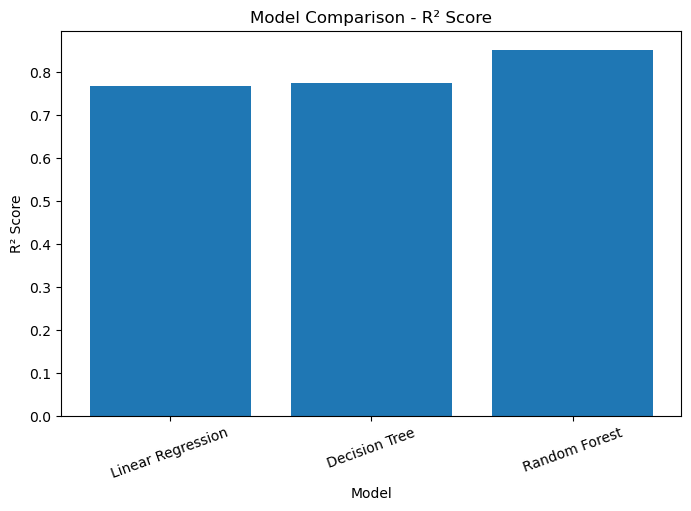

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(results_df["Model"], results_df["R2"])

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Comparison - R² Score")

plt.xticks(rotation=20)
plt.show()

### MAE Comparison

MAE represents the average absolute difference between actual and predicted laptop prices.
Lower MAE indicates better prediction accuracy.

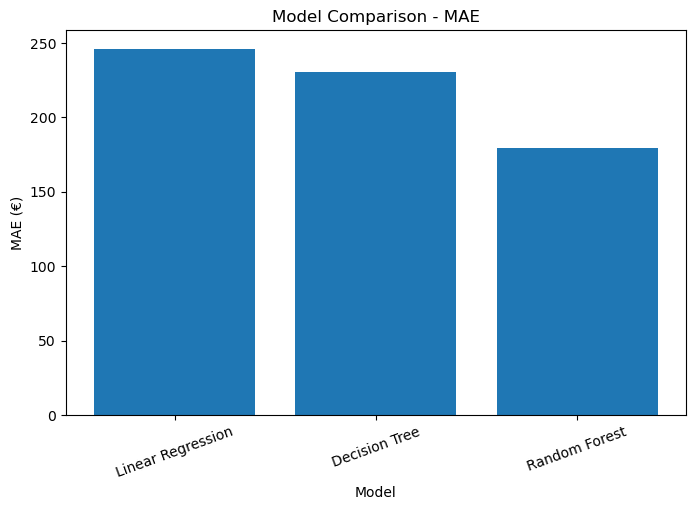

In [129]:
plt.figure(figsize=(8, 5))

plt.bar(results_df["Model"], results_df["MAE"])

plt.xlabel("Model")
plt.ylabel("MAE (€)")
plt.title("Model Comparison - MAE")

plt.xticks(rotation=20)
plt.show()

## 12. Saving Model Comparison Results

The model evaluation results are saved for future reference and documentation.

In [130]:
results_df.to_csv(
    r"D:\Smart-Laptop-Price-Predictor\data\model_results.csv",
    index=False
)

In [131]:
import os

print(os.path.exists(
    r"D:\Smart-Laptop-Price-Predictor\data\model_results.csv"
))

True


## 13. Lightweight Random Forest Hyperparameter Tuning

RandomizedSearchCV is used to find better Random Forest hyperparameters.
A small search space and single CPU process are used to reduce computational load.

In [15]:
from sklearn.model_selection import RandomizedSearchCV

In [16]:
param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [17]:
rf_tuning = RandomForestRegressor(
    random_state=42,
    n_jobs=1
)

In [18]:
random_search = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_grid,
    n_iter=6,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=1
)

In [19]:
random_search.fit(X_train_processed, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [10, 15, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 150, ...]}"
,n_iter,6
,scoring,'r2'
,n_jobs,1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [21]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV R²:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15}

Best CV R²:
0.8172230038210713


## 14. Tuned Random Forest Evaluation

The best hyperparameters obtained through RandomizedSearchCV are used to evaluate the tuned Random Forest on the unseen test dataset.

The tuned model is compared with the baseline Random Forest to determine whether hyperparameter tuning improved generalization performance.

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [25]:
best_rf = random_search.best_estimator_

best_rf_pred = best_rf.predict(X_test_processed)

best_rf_mae = mean_absolute_error(y_test, best_rf_pred)
best_rf_mse = mean_squared_error(y_test, best_rf_pred)
best_rf_rmse = np.sqrt(best_rf_mse)
best_rf_r2 = r2_score(y_test, best_rf_pred)

print("Tuned Random Forest Results")
print("MAE :", best_rf_mae)
print("MSE :", best_rf_mse)
print("RMSE:", best_rf_rmse)
print("R²  :", best_rf_r2)

Tuned Random Forest Results
MAE : 179.978281260815
MSE : 72332.04484145425
RMSE: 268.9461746176254
R²  : 0.8542689476368988


## 14. Tuned Random Forest Evaluation

The tuned Random Forest model is evaluated on the unseen test dataset using MAE, MSE, RMSE, and R².

These metrics are compared with the baseline Random Forest to determine whether hyperparameter tuning improved the model.

## 15. Final Model Performance Comparison

The performance of all trained regression models is compared using MAE, RMSE, and R² score.

Lower MAE and RMSE indicate better performance, while a higher R² score indicates better model performance.

In [27]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        246.211924,
        230.352503,
        179.463748,
        best_rf_mae
    ],
    "RMSE": [
        339.197176,
        334.679346,
        270.899883,
        best_rf_rmse
    ],
    "R2": [
        0.768193,
        0.774327,
        0.852144,
        best_rf_r2
    ]
})

results_df.round(4)

,Model,MAE,RMSE,R2
0,Linear Regression,246.2119,339.1972,0.7682
1,Decision Tree,230.3525,334.6793,0.7743
2,Random Forest,179.4637,270.8999,0.8521
3,Tuned Random Forest,179.9783,268.9462,0.8543


## 16. Saving Model Results

The model performance results are saved as a CSV file for future reference and comparison.

In [28]:
results_df.to_csv(
    r"D:\Smart-Laptop-Price-Predictor\data\model_results.csv",
    index=False
)

print("Model results saved successfully!")

Model results saved successfully!


In [29]:
import os

print(os.path.exists(
    r"D:\Smart-Laptop-Price-Predictor\data\model_results.csv"
))

True


## 17. Actual vs Predicted Prices

The actual laptop prices are compared with the prices predicted by the tuned Random Forest model.

A good regression model should produce predictions close to the actual prices.

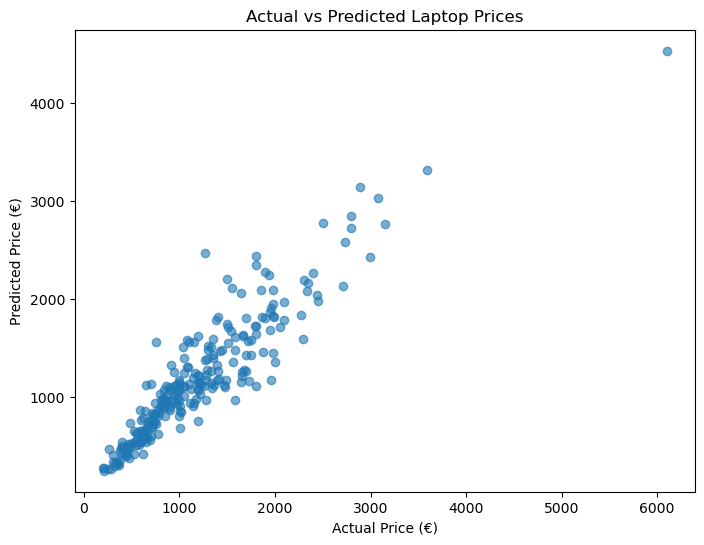

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_rf_pred,
    alpha=0.6
)

plt.xlabel("Actual Price (€)")
plt.ylabel("Predicted Price (€)")
plt.title("Actual vs Predicted Laptop Prices")

plt.show()

## 18. Feature Importance Analysis

Feature importance is used to identify which features contribute most to the Random Forest model's predictions.

This helps us understand which laptop specifications have the greatest influence on price.

In [31]:
feature_importance = best_rf.feature_importances_

print(len(feature_importance))

80


In [32]:
feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))
print(feature_names[:10])

80
['num__Inches' 'num__CPU_Frequency (GHz)' 'num__RAM (GB)'
 'num__Weight (kg)' 'num__SSD_GB' 'num__HDD_GB' 'num__Flash_GB'
 'num__Hybrid_GB' 'num__Total_Storage_GB' 'num__Resolution_Width']


In [33]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
2,num__RAM (GB),0.532102
3,num__Weight (kg),0.093129
35,cat__TypeName_Notebook,0.058504
1,num__CPU_Frequency (GHz),0.045381
60,cat__CPU_Family_Core i7,0.034625
4,num__SSD_GB,0.025891
0,num__Inches,0.022612
9,num__Resolution_Width,0.018433
59,cat__CPU_Family_Core i5,0.017116
10,num__Resolution_Height,0.015892


## 19. Top 15 Feature Importances

The top 15 most important features identified by the tuned Random Forest model are visualized below.

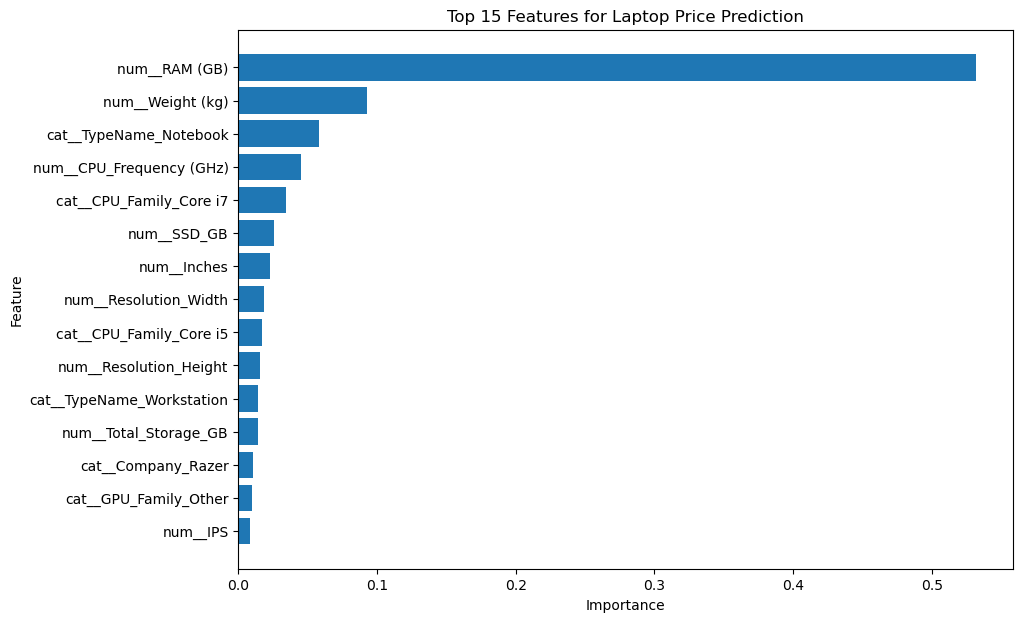

In [34]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features for Laptop Price Prediction")

plt.show()

In [35]:
importance_df.to_csv(
    r"D:\Smart-Laptop-Price-Predictor\data\feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


## 20. Saving the Final Model

The tuned Random Forest model and preprocessing pipeline are saved using Joblib so that they can be reused later without retraining the model.

In [36]:
import joblib

In [37]:
joblib.dump(
    best_rf,
    r"D:\Smart-Laptop-Price-Predictor\models\laptop_price_model.pkl"
)

['D:\\Smart-Laptop-Price-Predictor\\models\\laptop_price_model.pkl']

In [38]:
joblib.dump(
    preprocessor,
    r"D:\Smart-Laptop-Price-Predictor\models\preprocessor.pkl"
)

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [39]:
print(os.path.exists(
    r"D:\Smart-Laptop-Price-Predictor\models\laptop_price_model.pkl"
))

print(os.path.exists(
    r"D:\Smart-Laptop-Price-Predictor\models\preprocessor.pkl"
))

True
True


## 21. Residual Analysis

Residuals represent the difference between the actual and predicted laptop prices.

Residual analysis helps evaluate whether the model's errors are randomly distributed and whether there are any systematic prediction patterns.

In [41]:
residuals = y_test - best_rf_pred

print("Mean Residual:", residuals.mean())
print("Minimum Residual:", residuals.min())
print("Maximum Residual:", residuals.max())

Mean Residual: 8.475425028961576
Minimum Residual: -1197.7403777777777
Maximum Residual: 1562.7159999999994


## 22. Residual Plot

The residual plot shows the relationship between predicted prices and prediction errors.

Ideally, residuals should be distributed randomly around zero without a clear pattern.

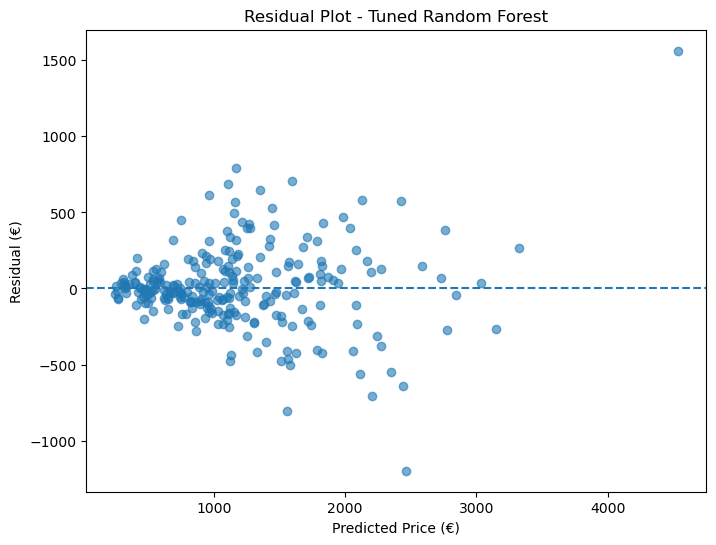

In [42]:
plt.figure(figsize=(8, 6))

plt.scatter(
    best_rf_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price (€)")
plt.ylabel("Residual (€)")
plt.title("Residual Plot - Tuned Random Forest")

plt.show()

## 23. Prediction Error Distribution

The distribution of residuals is visualized to understand the spread of prediction errors made by the tuned Random Forest model.

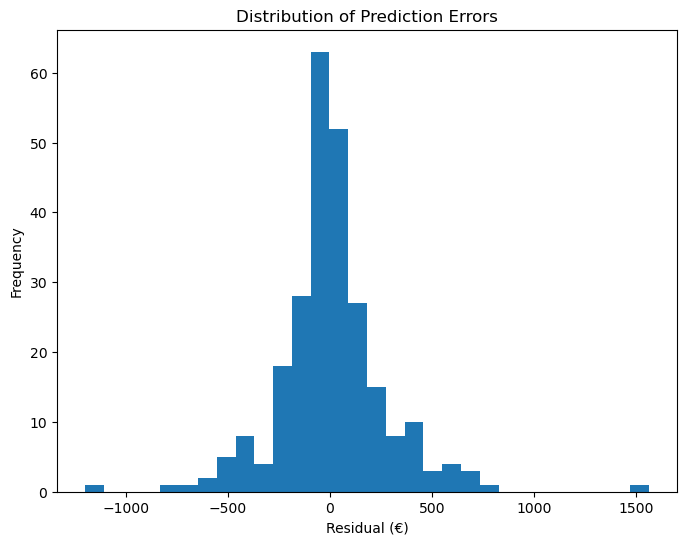

In [43]:
plt.figure(figsize=(8, 6))

plt.hist(
    residuals,
    bins=30
)

plt.xlabel("Residual (€)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.show()

## 24. Final Model Summary

After comparing multiple regression models and performing hyperparameter tuning, the Tuned Random Forest model was selected as the final model.

The model achieved an R² score of 0.8543 on the test dataset, indicating that it explains approximately 85.43% of the variation in laptop prices.

The final model and preprocessing pipeline were saved using Joblib for future predictions and deployment.